In [1]:
import yfinance as yf
import pandas as pd
from IPython.display import display, HTML

display(HTML("<style>.container { width:90% ! important; }</style>"))

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
#cob_date = '2025-04-01'  # Change this to the desired date

cob_date = '2025-12-31'  # Change this to the desired date

#cob_date = datetime.today().strftime('%Y-%m-%d')
cob_date_dt = datetime.strptime(cob_date, '%Y-%m-%d')
year_end_date = (cob_date_dt).replace(day=1, month=1) - timedelta(days=1)

print(f"Calculating for COB date: {cob_date}")
print(f"Year end date derived from COB date: {year_end_date.strftime('%Y-%m-%d')}")

Calculating for COB date: 2025-12-31
Year end date derived from COB date: 2024-12-31


In [37]:
indices_data = [
    {"index_type": "market", "name": "Nifty 50", "ticker": "^NSEI", "description": "Benchmark index of NSE (Top 50 companies)"},
    {"index_type": "market", "name": "Nifty Next 50", "ticker": "^NSMIDCP", "description": "The 50 companies after Nifty 50"},
   

    {"index_type": "market", "name": "S&P BSE SENSEX", "ticker": "^BSESN", "description": "Benchmark index of BSE (Top 30 companies)"},
    {"index_type": "sector", "name": "Nifty Financial Services", "ticker": "NIFTY_FIN_SERVICE.NS", "description": "Includes banks, NBFCs, and insurance (Finnifty)"},
    {"index_type": "sector", "name": "Nifty Bank", "ticker": "^NSEBANK", "description": "Most liquid banking stocks (Derivative favorite)"},
    {"index_type": "sector", "name": "Nifty IT", "ticker": "^CNXIT", "description": "Information Technology sector"},
    {"index_type": "sector", "name": "Nifty PSE", "ticker": "^CNXPSE", "description": "Public Sector Enterprises"},

    #{"index_type": 6, "name": "Nifty Midcap 100", "ticker": "^NSEMDCP100", "description": "Top 100 Midcap companies"},
    #{"index_type": 8, "name": "Nifty Smallcap 100", "ticker": "^CNXSC", "description": "Top 100 Smallcap companies"},
    {"index_type": "sector", "name": "Nifty Pharma", "ticker": "^CNXPHARMA", "description": "Pharmaceutical sector"},
    {"index_type": "sector", "name": "Nifty Auto", "ticker": "^CNXAUTO", "description": "Automobile sector"},
    {"index_type": "sector", "name": "Nifty FMCG", "ticker": "^CNXFMCG", "description": "Fast-moving consumer goods"},
    {"index_type": "sector", "name": "Nifty PSU Bank", "ticker": "^CNXPSUBANK", "description": "Public sector (Government) banks"},
    {"index_type": "sector", "name": "Nifty Realty", "ticker": "^CNXREALTY", "description": "Real estate sector"},
    {"index_type": "sector", "name": "Nifty Energy", "ticker": "^CNXENERGY", "description": "Energy and power sector"},
    {"index_type": "market", "name": "Nifty 500", "ticker": "^CRSLDX", "description": "Broad market index (Top 500 companies)"},
    {"index_type": "sector", "name": "Nifty Infrastructure", "ticker": "^CNXINFRA", "description": "Infrastructure sector"},
    {"index_type": "sector", "name": "Nifty Media", "ticker": "^CNXMEDIA", "description": "Media and entertainment sector"},
    {"index_type": "sector", "name": "Nifty Private Bank", "ticker": "NIFTY_PVT_BANK.NS", "description": "Private sector banks"},
    {"index_type": "market", "name": "Nifty 100", "ticker": "^CNX100", "description": "Top 100 companies by market cap"},
   # {"index_type": 21, "name": "S&P BSE Bankex", "ticker": "^BSEBANK", "description": "BSE's banking sector index"},
   # {"index_type": 22, "name": "S&P BSE IT", "ticker": "^BSEIT", "description": "BSE's IT sector index"},
    {"index_type": "comm", "name": "Nifty Commodities", "ticker": "^CNXCMDT", "description": "Commodity-linked companies"},
    {"index_type": "comm", "name": "Nifty Metal", "ticker": "^CNXMETAL", "description": "Metal and mining sector"}
   
    #{"index_type": 24, "name": "Nifty Consumption", "ticker": "^CNXCONSUMP", "description": "Domestic consumption-linked companies"},
   ]

In [38]:
indices_df = pd.DataFrame(indices_data)
indices_df.head()

,index_type,name,ticker,description
0,market,Nifty 50,^NSEI,Benchmark index of NSE (Top 50 companies)
1,market,Nifty Next 50,^NSMIDCP,The 50 companies after Nifty 50
2,market,S&P BSE SENSEX,^BSESN,Benchmark index of BSE (Top 30 companies)
3,sector,Nifty Financial Services,NIFTY_FIN_SERVICE.NS,"Includes banks, NBFCs, and insurance (Finnifty)"
4,sector,Nifty Bank,^NSEBANK,Most liquid banking stocks (Derivative favorite)


In [39]:
indices = indices_df.set_index('ticker')['name'].to_dict()
#indices

{'market': '^CNX100', 'sector': 'NIFTY_PVT_BANK.NS', 'comm': '^CNXMETAL'}

In [32]:
def fetch_data(tickers, start_dt, end_dt):
    df = yf.download(tickers, start=start_dt, end=end_dt)
    df = df['Close']
    return df

In [33]:
dashboard_data = {}
for  ticker,name in indices.items():
    dashboard_data[name] = fetch_data(ticker, start_dt = f"{year_end_date.strftime('%Y-%m-%d')}", end_dt=cob_date)

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

In [34]:
dashboard_data

{'Nifty 50': Ticker             ^NSEI
 Date                    
 2024-12-31  23644.800781
 2025-01-01  23742.900391
 2025-01-02  24188.650391
 2025-01-03  24004.750000
 2025-01-06  23616.050781
 ...                  ...
 2025-12-23  26177.150391
 2025-12-24  26142.099609
 2025-12-26  26042.300781
 2025-12-29  25942.099609
 2025-12-30  25938.849609
 
 [249 rows x 1 columns],
 'Nifty Bank': Ticker          ^NSEBANK
 Date                    
 2024-12-31  50860.199219
 2025-01-02  51605.550781
 2025-01-03  50988.800781
 2025-01-06  49922.000000
 2025-01-07  50202.148438
 ...                  ...
 2025-12-23  59299.550781
 2025-12-24  59183.601562
 2025-12-26  59011.351562
 2025-12-29  58932.351562
 2025-12-30  59171.250000
 
 [247 rows x 1 columns],
 'S&P BSE SENSEX': Ticker            ^BSESN
 Date                    
 2024-12-31  78139.007812
 2025-01-01  78507.406250
 2025-01-02  79943.710938
 2025-01-03  79223.109375
 2025-01-06  77964.992188
 ...                  ...
 2025-12-23  85524

Asset Class: Nifty 50


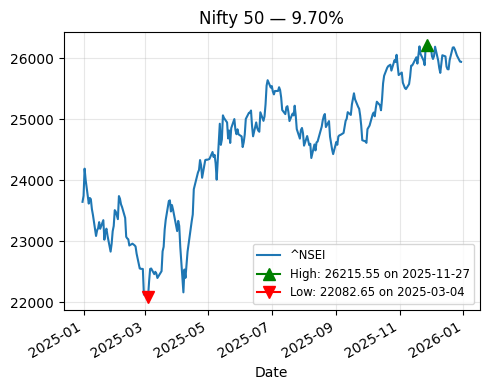

Asset Class: Nifty Bank


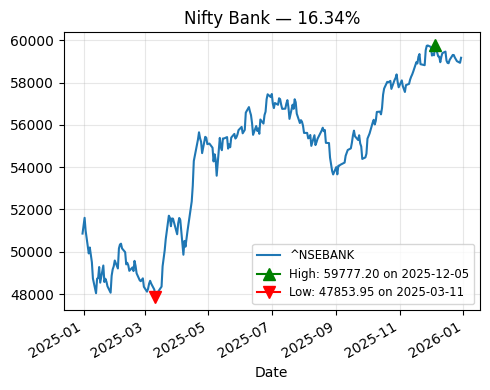

Asset Class: S&P BSE SENSEX


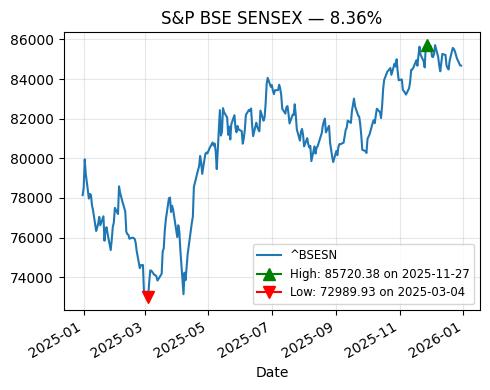

Asset Class: Nifty Financial Services


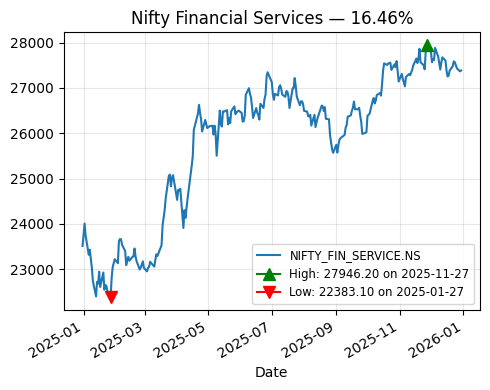

Asset Class: Nifty IT


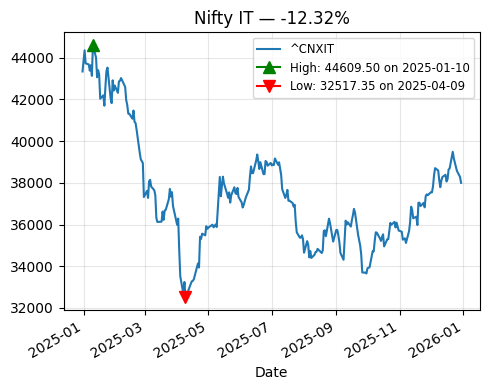

Asset Class: Nifty Next 50


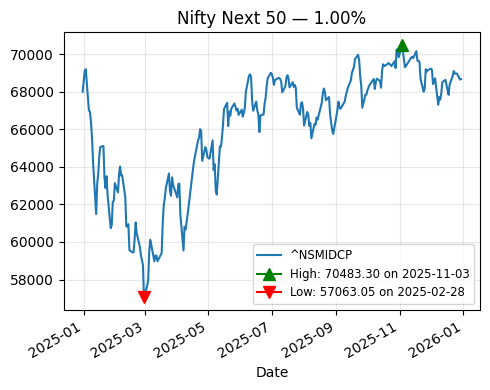

Asset Class: Nifty Pharma


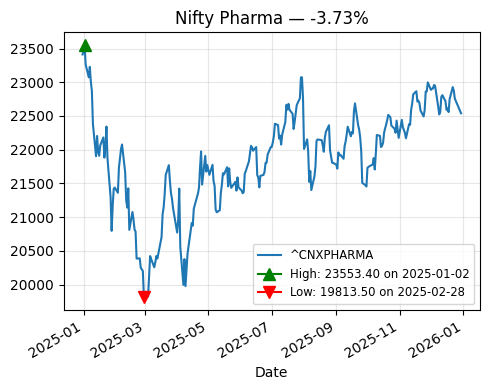

Asset Class: Nifty Auto


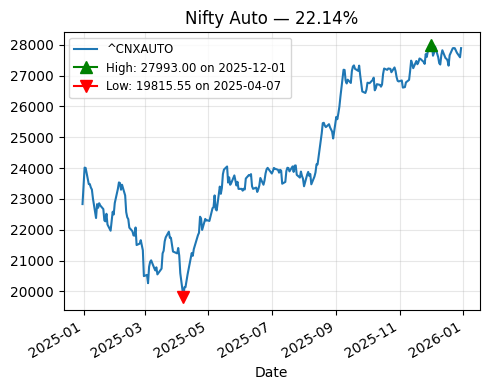

Asset Class: Nifty FMCG


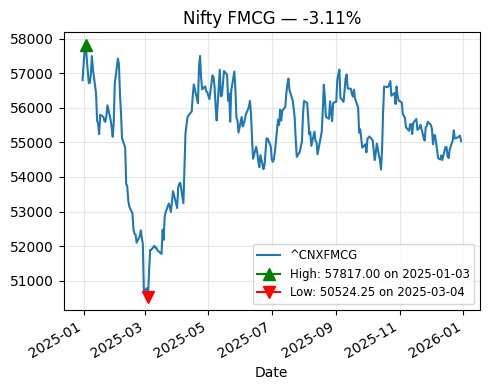

Asset Class: Nifty Metal


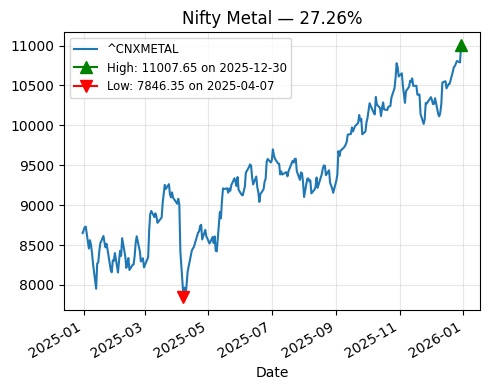

Asset Class: Nifty PSU Bank


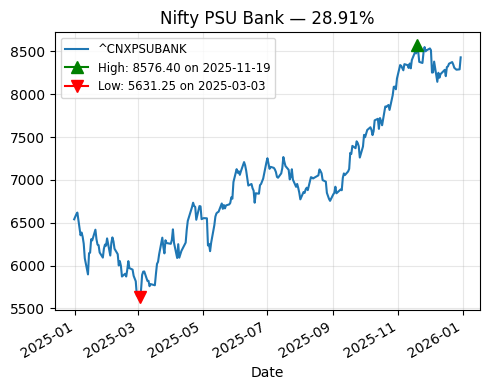

Asset Class: Nifty Realty


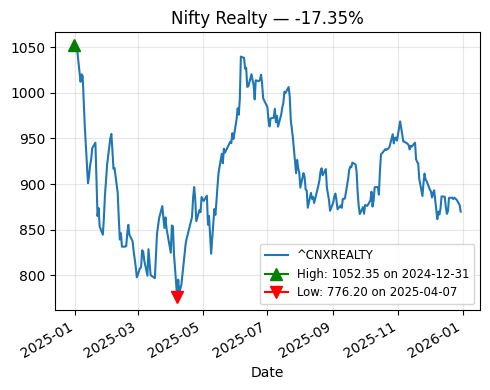

Asset Class: Nifty Energy


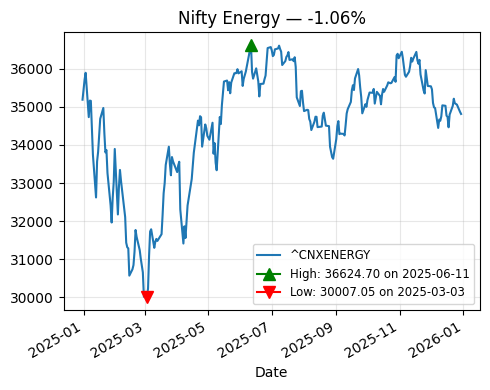

Asset Class: Nifty 500


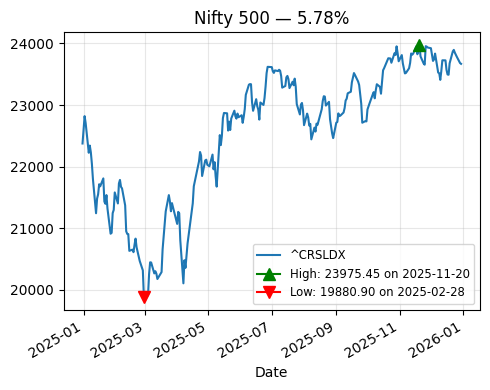

Asset Class: Nifty Infrastructure


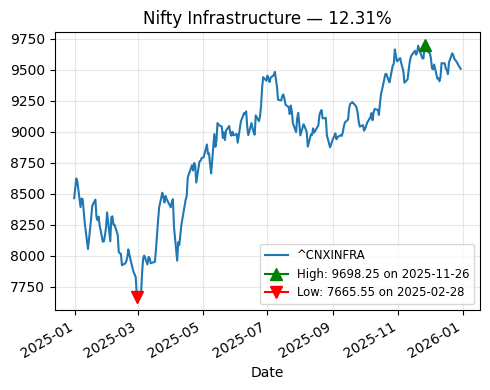

Asset Class: Nifty Media


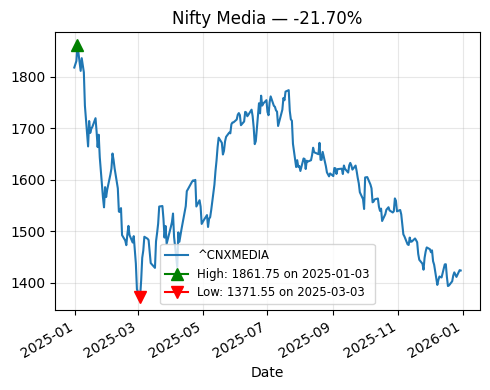

Asset Class: Nifty Private Bank


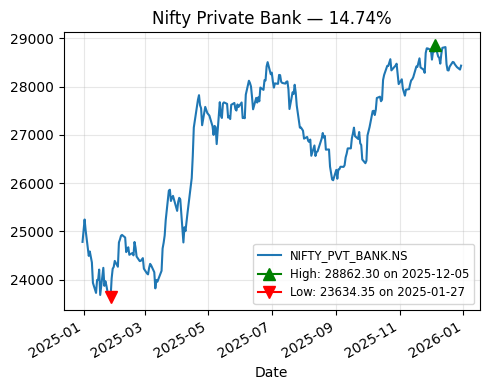

Asset Class: Nifty 100


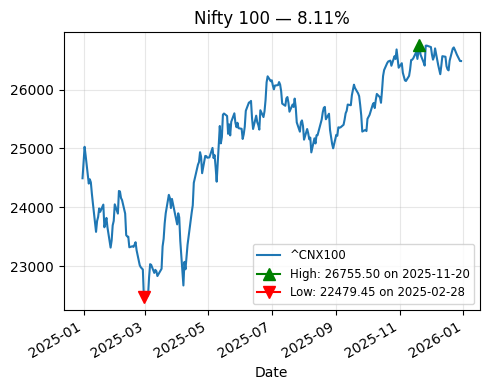

Asset Class: Nifty Commodities


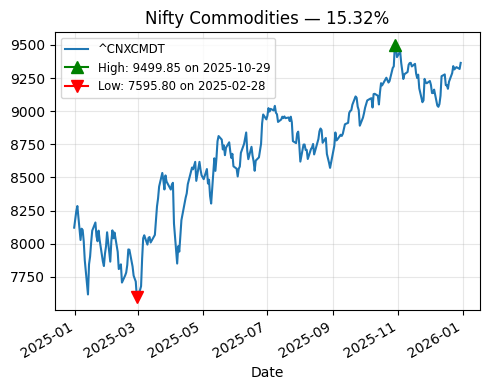

Asset Class: Nifty PSE


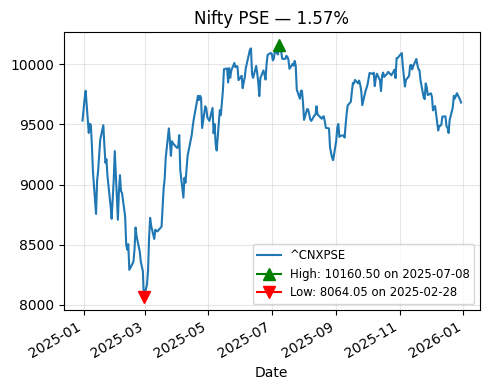

In [36]:
# Display data and charts
for name, df in dashboard_data.items():
    print(f"Asset Class: {name}")
    fig, axes = plt.subplots(ncols=len(df.columns), nrows=1, figsize=(5 * len(df.columns),4))

    # Normalize axes to a list when only one subplot exists
    axes_list = axes if hasattr(axes, '__len__') else [axes]

    for i, column in enumerate(df.columns):
        ax = axes_list[i]
        series = df[column].dropna()
        if series.empty:
            ax.set_title(indices.get(column, column))
            continue

        # Ensure chronological order
        series = series.sort_index()

        # Compute percent return over the period (first available -> last available)
        try:
            start_val = series.iloc[0]
            end_val = series.iloc[-1]
            pct_return = (end_val / start_val - 1) * 100
        except Exception:
            pct_return = float('nan')

        # Plot series with percent return in title
        series.plot(ax=ax, title=f"{indices.get(column, column)} — {pct_return:.2f}%", xlabel=None)

        # Find high and low points
        high_idx = series.idxmax()
        high_val = series.max()
        low_idx = series.idxmin()
        low_val = series.min()

        # Plot markers for high and low
        ax.plot(high_idx, high_val, marker='^', color='green', markersize=8, label=f"High: {high_val:.2f} on {pd.to_datetime(high_idx).strftime('%Y-%m-%d')}")
        ax.plot(low_idx, low_val, marker='v', color='red', markersize=8, label=f"Low: {low_val:.2f} on {pd.to_datetime(low_idx).strftime('%Y-%m-%d')}")

        # Add legend and grid
        ax.legend(fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()  # Adjust subplot spacing
    plt.show()